In [42]:
import pandas as pd

ST_PREBIVALCEV = pd.read_csv('podatki/prebivalstvo_obcine.csv')
PRIHODI = pd.read_csv('podatki/turizem_prihodi.csv')





ZDRUŽEVANJE PODATKOV

In [52]:
pd.set_option('display.max_rows', 200)

ST_PREBIVALCEV = ST_PREBIVALCEV[ST_PREBIVALCEV['obcina'] != 'SLOVENIJA'].copy()
PRIHODI = PRIHODI[PRIHODI['obcina'] != 'SLOVENIJA'].copy()

ST_PREBIVALCEV['obcina_koda'] = ST_PREBIVALCEV['obcina'].str[:3]
ST_PREBIVALCEV['obcina_ime'] = ST_PREBIVALCEV['obcina'].str[4:]

# enak ključ za obcine
ST_PREBIVALCEV['kljuc'] = ST_PREBIVALCEV['obcina_ime'].str.lower().str.strip()
PRIHODI['kljuc'] = PRIHODI['obcina'].str.lower().str.strip()


# PRIHODI['leto'] = PRIHODI['leto'].astype(int)
# ST_PREBIVALCEV['leto'] = ST_PREBIVALCEV['leto'].astype(int)

SKUPNA_TABELA = PRIHODI.merge(
    ST_PREBIVALCEV[['kljuc', 'obcina_koda', 'leto', 'vrednost']],
    on=['kljuc', 'leto'],
    suffixes=('_tur', '_preb')
)
SKUPNA_TABELA = SKUPNA_TABELA.rename(columns={'vrednost_tur': 'turizem', 'vrednost_preb': 'prebivalci'})

SKUPNA_TABELA

,obcina,poreklo,meritev,leto,turizem,kljuc,obcina_koda,prebivalci
0,Ajdovščina,Domači,Prihodi turistov,2018,3913.0,ajdovščina,001,19130
1,Ajdovščina,Domači,Prihodi turistov,2019,3223.0,ajdovščina,001,19249
2,Ajdovščina,Domači,Prihodi turistov,2020,4642.0,ajdovščina,001,19418
3,Ajdovščina,Domači,Prihodi turistov,2021,5949.0,ajdovščina,001,19704
4,Ajdovščina,Domači,Prihodi turistov,2022,5667.0,ajdovščina,001,19727
...,...,...,...,...,...,...,...,...
6779,Žužemberk,Tuji,Prenočitve turistov,2021,1175.0,žužemberk,193,4741
6780,Žužemberk,Tuji,Prenočitve turistov,2022,2719.0,žužemberk,193,4719
6781,Žužemberk,Tuji,Prenočitve turistov,2023,3878.0,žužemberk,193,4681
6782,Žužemberk,Tuji,Prenočitve turistov,2024,3832.0,žužemberk,193,4663


TURISTI GLEDE NA ST PREBIVALCEV

In [53]:
# 0. Priprava podatkov o prenočitvah
prenocitve_df = SKUPNA_TABELA[SKUPNA_TABELA['meritev'] == 'Prenočitve turistov'].copy()

prenocitve_skupaj = prenocitve_df.groupby(
    ['leto', 'obcina_koda', 'obcina', 'prebivalci'], 
    as_index=False
)['turizem'].sum()

prenocitve_skupaj = prenocitve_skupaj.rename(columns={'turizem': 'skupaj_prenocitve'})
prenocitve_skupaj['prenocitve_na_prebivalca'] = prenocitve_skupaj['skupaj_prenocitve'] / prenocitve_skupaj['prebivalci']


# 1. Izračunamo povprečja po občinah skozi vsa leta
povprecja_obcine = (
    prenocitve_skupaj
    .groupby(['obcina_koda', 'obcina'], as_index=False)
    .agg({
        'skupaj_prenocitve': 'mean',
        'prebivalci': 'mean',
        'prenocitve_na_prebivalca': 'mean'
    })
)

# 2. Zaokrožimo vrednosti na cele številke in 2 decimalni mesti za razmerje
povprecja_obcine['skupaj_prenocitve'] = povprecja_obcine['skupaj_prenocitve'].round(0).astype(int)
povprecja_obcine['prebivalci'] = povprecja_obcine['prebivalci'].round(0).astype(int)
povprecja_obcine['prenocitve_na_prebivalca'] = povprecja_obcine['prenocitve_na_prebivalca'].round(2)

# 3. Razvrstimo po povprečnem število prenočitev na prebivalca in vzamemo TOP 10
top10_povprecje = (
    povprecja_obcine
    .sort_values(by='prenocitve_na_prebivalca', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

# Preimenujemo stolpce za lepši prikaz
top10_povprecje = top10_povprecje.rename(columns={
    'skupaj_prenocitve': 'povprecno_prenocitev_na_leto',
    'prebivalci': 'povprecno_prebivalcev',
    'prenocitve_na_prebivalca': 'prenocitve_na_prebivalca_povprecje'
})

# Izpišemo končno tabelo
top10_povprecje[['obcina', 'povprecno_prenocitev_na_leto', 'povprecno_prebivalcev', 'prenocitve_na_prebivalca_povprecje']]

,obcina,povprecno_prenocitev_na_leto,povprecno_prebivalcev,prenocitve_na_prebivalca_povprecje
0,Bovec,500058,3087,162.32
1,Kranjska Gora,842835,5898,147.52
2,Bohinj,726039,5327,136.32
3,Bled,961854,8068,119.22
4,Podčetrtek,392874,3546,110.73
5,Piran/Pirano,1752967,18046,97.15
6,Ankaran/Ancarano,292834,3293,88.64
7,Moravske Toplice,511221,5914,86.44
8,Veržej,99504,1340,74.28
9,Solčava,33786,515,65.54


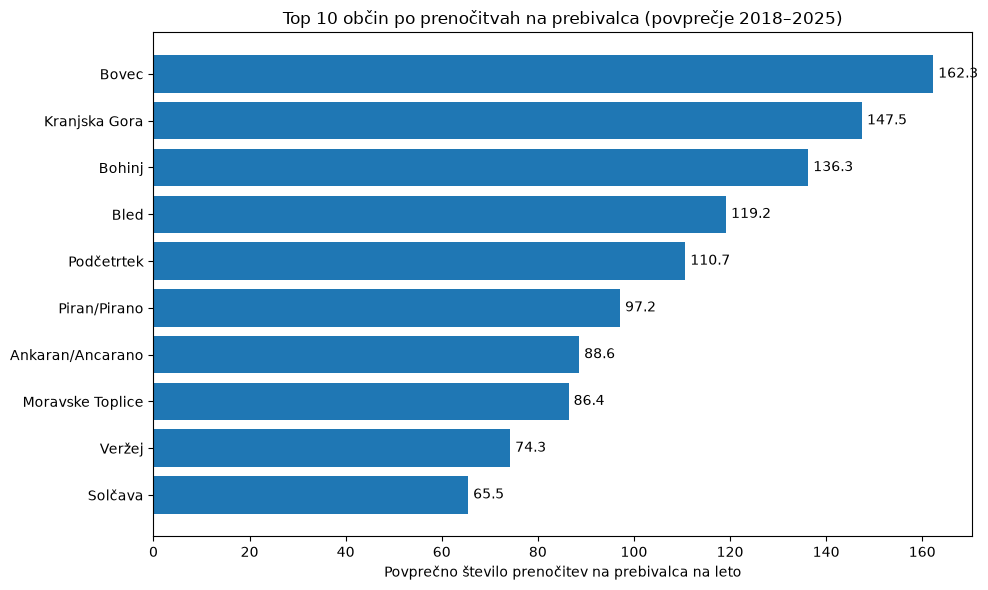

In [56]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    top10_povprecje['obcina'],
    top10_povprecje['prenocitve_na_prebivalca_povprecje']
)
ax.invert_yaxis()   # največja vrednost na vrhu

ax.set_xlabel('Povprečno število prenočitev na prebivalca na leto')
ax.set_title('Top 10 občin po prenočitvah na prebivalca (povprečje 2018–2025)')

# vrednosti ob stolpcih
for i, v in enumerate(top10_povprecje['prenocitve_na_prebivalca_povprecje']):
    ax.text(v + 1, i, f'{v:.1f}', va='center')

plt.tight_layout()
plt.show()

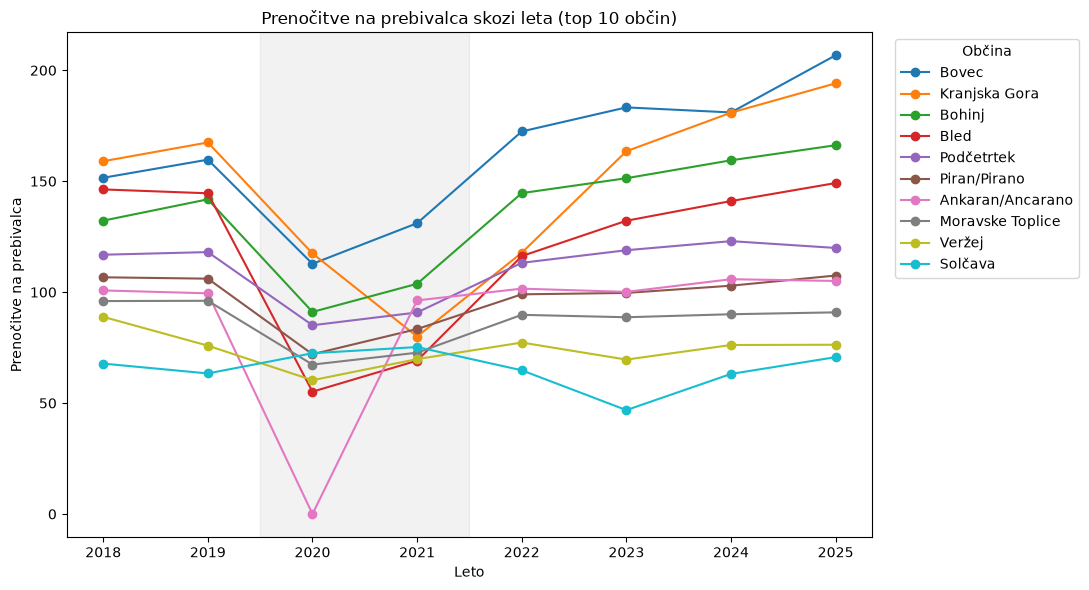

In [57]:
top_obcine = top10_povprecje['obcina'].tolist()

trend = (
    prenocitve_skupaj[prenocitve_skupaj['obcina'].isin(top_obcine)]
    .pivot(index='leto', columns='obcina', values='prenocitve_na_prebivalca')
    .reindex(range(2018, 2026))        # manjkajoča leta ostanejo kot vrzel
)
trend = trend[top_obcine]              # enak vrstni red kot v lestvici

fig, ax = plt.subplots(figsize=(11, 6))
trend.plot(ax=ax, marker='o')

ax.set_xlabel('Leto')
ax.set_ylabel('Prenočitve na prebivalca')
ax.set_title('Prenočitve na prebivalca skozi leta (top 10 občin)')
ax.legend(title='Občina', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.axvspan(2019.5, 2021.5, alpha=0.1, color='gray')   # covidni leti 2020 in 2021

plt.tight_layout()
plt.show()

Združena raziskovalna tema: domači proti tujim gostom

Vprašanje: Katere občine so bolj priljubljene med tujci in katere med domačini?

Glavni kazalnik: delež tujih prenočitev v občini

delez_tujih = tuji / (domači + tuji) * 100

Ta delež primerjaš s slovenskim povprečjem (iz vrstice SLOVENIJA). Prenočitve veljajo za glavno meritev. Za leto 2019 je delež tujih v državi okoli 72 % (11,37 / (11,37 + 4,40) milijona).

Občine nad državnim deležem so bolj »tuje« (npr. Bled, Bohinj, Piran).
Občine pod državnim deležem so bolj »domače« (verjetno termalna zdravilišča in manjši kraji v notranjosti).

In [46]:
# 1. Izračun državnega povprečja za leto 2025 (Prenočitve)
slo_2025 = PODATKI_SLOVENIJA[
    (PODATKI_SLOVENIJA['meritev'] == 'Prenočitve turistov') & 
    (PODATKI_SLOVENIJA['leto'] == 2025)
].pivot(index='leto', columns='poreklo', values='turizem')

delez_tujih_slo_2025 = (slo_2025['Tuji'] / (slo_2025['Domači'] + slo_2025['Tuji']) * 100).values[0]

print(f"Državno povprečje deleža tujih prenočitev (2025): {delez_tujih_slo_2025:.2f}%\n")

# 2. Priprava podatkov po občinah za leto 2025
prenocitve_2025 = SKUPNA_TABELA[
    (SKUPNA_TABELA['meritev'] == 'Prenočitve turistov') & 
    (SKUPNA_TABELA['leto'] == 2025)
].copy()

obcine_2025 = prenocitve_2025.pivot(
    index=['obcina_koda', 'obcina'], 
    columns='poreklo', 
    values='turizem'
).reset_index()

# Izračun skupnih prenočitev in deleža tujcev
obcine_2025['Skupaj'] = obcine_2025['Domači'] + obcine_2025['Tuji']
obcine_2025['delez_tujih'] = (obcine_2025['Tuji'] / obcine_2025['Skupaj']) * 100

# Filtriramo občine z vsaj 10.000 prenočitvami za bolj reprezentativne rezultate
obcine_znatne_2025 = obcine_2025[obcine_2025['Skupaj'] >= 10000].copy()
obcine_znatne_2025['delez_tujih'] = obcine_znatne_2025['delez_tujih'].round(2)

# Izpis TOP 10 "tujih" občin
print("=== TOP 10 OBČIN Z NAJVIŠJIM % TUJIH GOSTOV (2025) ===")
print(obcine_znatne_2025.sort_values(by='delez_tujih', ascending=False)[['obcina', 'Skupaj', 'delez_tujih']].head(10).to_string(index=False))

print("\n" + "="*50 + "\n")

# Izpis TOP 10 "domačih" občin
print("=== TOP 10 OBČIN Z NAJVIŠJIM % DOMAČIH GOSTOV (2025) ===")
print(obcine_znatne_2025.sort_values(by='delez_tujih', ascending=True)[['obcina', 'Skupaj', 'delez_tujih']].head(10).to_string(index=False))

Državno povprečje deleža tujih prenočitev (2025): 74.87%

=== TOP 10 OBČIN Z NAJVIŠJIM % TUJIH GOSTOV (2025) ===
    obcina    Skupaj  delez_tujih
Radovljica  503658.0        97.04
      Bled 1216324.0        96.42
 Ljubljana 2844129.0        96.01
   Medvode   18525.0        95.15
     Pivka   25762.0        94.96
 Brezovica   17530.0        94.81
   Domžale   52904.0        94.43
    Šenčur   33739.0        94.43
  Postojna  170501.0        93.77
     Bovec  621121.0        93.03


=== TOP 10 OBČIN Z NAJVIŠJIM % DOMAČIH GOSTOV (2025) ===
           obcina   Skupaj  delez_tujih
Šmarješke Toplice 120722.0        14.47
         Mislinja  32539.0        14.85
 Selnica ob Dravi  10088.0        15.56
           Dobrna 115386.0        16.32
           Veržej 105208.0        17.16
           Kostel  11370.0        19.70
Dolenjske Toplice 129288.0        23.30
            Semič  14285.0        24.25
         Črnomelj  48306.0        24.29
         Ljutomer  68673.0        26.65


In [47]:
# 0. Priprava občinskih podatkov za leto 2019 (če še niso pripravljeni)
prenocitve_2019 = SKUPNA_TABELA[
    (SKUPNA_TABELA['meritev'] == 'Prenočitve turistov') & 
    (SKUPNA_TABELA['leto'] == 2019)
].copy()

obcine_2019 = prenocitve_2019.pivot(
    index=['obcina_koda', 'obcina'], 
    columns='poreklo', 
    values='turizem'
).reset_index()

obcine_2019['Skupaj'] = obcine_2019['Domači'] + obcine_2019['Tuji']
obcine_2019['delez_tujih'] = (obcine_2019['Tuji'] / obcine_2019['Skupaj']) * 100

# 1. Izračunamo državni delež za 2019 in 2025
slo_2019 = PODATKI_SLOVENIJA[
    (PODATKI_SLOVENIJA['meritev'] == 'Prenočitve turistov') & 
    (PODATKI_SLOVENIJA['leto'] == 2019)
].pivot(index='leto', columns='poreklo', values='turizem')

delez_tujih_slo = (slo_2019['Tuji'] / (slo_2019['Domači'] + slo_2019['Tuji']) * 100).values[0]

slo_2025 = PODATKI_SLOVENIJA[
    (PODATKI_SLOVENIJA['meritev'] == 'Prenočitve turistov') & 
    (PODATKI_SLOVENIJA['leto'] == 2025)
].pivot(index='leto', columns='poreklo', values='turizem')

delez_tujih_slo_2025 = (slo_2025['Tuji'] / (slo_2025['Domači'] + slo_2025['Tuji']) * 100).values[0]

# 2. Priprava podatkov po občinah za primerjavo
p2019 = obcine_2019[['obcina_koda', 'obcina', 'delez_tujih', 'Skupaj']].rename(
    columns={'delez_tujih': 'delez_tujih_2019', 'Skupaj': 'skupaj_2019'}
)

p2025 = obcine_2025[['obcina_koda', 'delez_tujih', 'Skupaj']].rename(
    columns={'delez_tujih': 'delez_tujih_2025', 'Skupaj': 'skupaj_2025'}
)

primerjava = p2019.merge(p2025, on='obcina_koda')
primerjava = primerjava[primerjava['skupaj_2025'] >= 10000].copy()

primerjava['sprememba_o_t'] = primerjava['delez_tujih_2025'] - primerjava['delez_tujih_2019']

primerjava['delez_tujih_2019'] = primerjava['delez_tujih_2019'].round(2)
primerjava['delez_tujih_2025'] = primerjava['delez_tujih_2025'].round(2)
primerjava['sprememba_o_t'] = primerjava['sprememba_o_t'].round(2)

sprememba_slo = delez_tujih_slo_2025 - delez_tujih_slo

# Izpis državnih sprememb
print(f"Državni delež tujcev 2019: {delez_tujih_slo:.2f}%")
print(f"Državni delež tujcev 2025: {delez_tujih_slo_2025:.2f}%")
print(f"Sprememba za celo Slovenijo: {sprememba_slo:+.2f} odstotnih točk\n")
print("="*60 + "\n")

print("=== TOP 10 OBČIN Z NAJVEČJO RASTJO DELEŽA TUJIH GOSTOV (2019 -> 2025) ===")
print(
    primerjava.sort_values(by='sprememba_o_t', ascending=False)[
        ['obcina', 'delez_tujih_2019', 'delez_tujih_2025', 'sprememba_o_t']
    ]
    .head(10)
    .to_string(index=False)
)

print("\n" + "="*60 + "\n")

print("=== TOP 10 OBČIN Z NAJVEČJIM PADCEM DELEŽA TUJIH GOSTOV (2019 -> 2025) ===")
print(
    primerjava.sort_values(by='sprememba_o_t', ascending=True)[
        ['obcina', 'delez_tujih_2019', 'delez_tujih_2025', 'sprememba_o_t']
    ]
    .head(10)
    .to_string(index=False)
)

Državni delež tujcev 2019: 72.08%
Državni delež tujcev 2025: 74.87%
Sprememba za celo Slovenijo: +2.79 odstotnih točk


=== TOP 10 OBČIN Z NAJVEČJO RASTJO DELEŽA TUJIH GOSTOV (2019 -> 2025) ===
              obcina  delez_tujih_2019  delez_tujih_2025  sprememba_o_t
             Mozirje             53.86             76.67          22.81
                Luče             56.59             74.34          17.75
              Cerkno             48.19             65.38          17.19
     Hoče - Slivnica             41.69             54.57          12.88
             Solčava             54.55             66.38          11.83
               Semič             13.19             24.25          11.06
               Gorje             80.56             90.39           9.82
Miren - Kostanjevica             65.78             75.57           9.79
   Koper/Capodistria             71.45             81.00           9.56
            Jezersko             75.41             84.59           9.18


=== TOP 10 O

In [49]:
import pandas as pd

# 1. Pripravimo prenočitve po občinah in letih
prenocitve = SKUPNA_TABELA[SKUPNA_TABELA['meritev'] == 'Prenočitve turistov'].groupby(
    ['obcina_koda', 'obcina', 'leto'], as_index=False
)['turizem'].sum().rename(columns={'turizem': 'prenocitve'})

# 2. Ločimo leto 2019 (osnova za primerjavo)
p2019 = prenocitve[prenocitve['leto'] == 2019][['obcina_koda', 'obcina', 'prenocitve']].rename(
    columns={'prenocitve': 'prenocitve_2019'}
)

# Filtriramo občine z vsaj 10.000 prenočitvami v 2019 za reprezentativnost
p2019 = p2019[p2019['prenocitve_2019'] >= 10000].copy()

# 3. Združimo podatke ostalih let in poiščemo prvo leto okrevanja
p_ostala = prenocitve[prenocitve['leto'] > 2019]
zdruzeno = p_ostala.merge(p2019, on=['obcina_koda', 'obcina'])

# Preverimo, kje so prenočitve >= 2019
dosegle_2019 = zdruzeno[zdruzeno['prenocitve'] >= zdruzeno['prenocitve_2019']].copy()

# Poiščemo najzgodnejše (prvo) leto za vsako občino
prvo_leto_okrevanja = dosegle_2019.groupby(['obcina_koda', 'obcina'], as_index=False).agg(
    leto_okrevanja=('leto', 'min'),
    prenocitve_ob_prehodu=('prenocitve', 'first')
)

# Združimo nazaj z osnovno tabelo 2019, da dobimo tudi tiste občine, ki do 2025 še niso okrevale
rezultat_okrevanja = p2019.merge(prvo_leto_okrevanja, on=['obcina_koda', 'obcina'], how='left')

# Če občina še ni presegla, vpišemo tekst
rezultat_okrevanja['leto_okrevanja_prikaz'] = rezultat_okrevanja['leto_okrevanja'].fillna('Še ni presegla')
rezultat_okrevanja['prenocitve_2019'] = rezultat_okrevanja['prenocitve_2019'].astype(int)

# 4. Razvrstimo glede na leto okrevanja
# Najhitrejša: tista z najnižjim letom (npr. 2020 ali 2021)
najhitrejse = rezultat_okrevanja.sort_values(by=['leto_okrevanja', 'prenocitve_2019'], ascending=[True, False])

print("=== TOP 10 NAJHITREJŠIH OBČIN (PRVE DOSEGLE / PRESEGLE LETO 2019) ===")
print(najhitrejse[['obcina', 'prenocitve_2019', 'leto_okrevanja_prikaz']].head(10).to_string(index=False))

print("\n" + "="*60 + "\n")

# Najpočasnejša: tista z najvišjim letom ali "Še ni presegla"
najpocasnejse = rezultat_okrevanja.sort_values(
    by=['leto_okrevanja'], ascending=False, na_position='first'
)

print("=== TOP 10 NAJPOČASNEJŠIH OBČIN (NAJKASNEJE ALI ŠE NISO PRESEGLE 2019) ===")
print(najpocasnejse[['obcina', 'prenocitve_2019', 'leto_okrevanja_prikaz']].head(10).to_string(index=False))

=== TOP 10 NAJHITREJŠIH OBČIN (PRVE DOSEGLE / PRESEGLE LETO 2019) ===
           obcina  prenocitve_2019 leto_okrevanja_prikaz
         Črnomelj            44105                2020.0
          Metlika            38167                2020.0
          Solčava            32567                2020.0
         Jezersko            21515                2020.0
         Mislinja            17204                2020.0
Koper/Capodistria           293622                2021.0
         Ljutomer            68307                2021.0
             Brda            44845                2021.0
          Kočevje            24939                2021.0
           Ljubno            20532                2021.0


=== TOP 10 NAJPOČASNEJŠIH OBČIN (NAJKASNEJE ALI ŠE NISO PRESEGLE 2019) ===
               obcina  prenocitve_2019 leto_okrevanja_prikaz
                Celje            74101        Še ni presegla
Cerklje na Gorenjskem            93361        Še ni presegla
               Divača            26879     